In [38]:
import os
import random
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from PIL import Image
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path(".")
DATA_DIR    = PROJECT_ROOT / "data"
RUNS_DIR    = PROJECT_ROOT / "runs"
STREET_DIR  = PROJECT_ROOT / "street_photos"
RESULTS_DIR = PROJECT_ROOT / "street_results"

In [ ]:
ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY", "")

IMG_SIZE    = 640
BATCH_SIZE  = 32
EPOCHS_PRE  = 15
EPOCHS_MAIN = 30
PATIENCE    = 4 # если val mAP не улучшается PATIENCE эпох подряд — прерываем обучение
MODEL_BASE  = "yolov8n.pt"
DEVICE      = 0     # GPU

SVHN_DIR   = DATA_DIR / "svhn"
NUMDET_DIR = DATA_DIR / "numberdetection"

print(f"Модель: {MODEL_BASE}, img_size: {IMG_SIZE}, batch: {BATCH_SIZE}")
print(f"Эпох предобучения: {EPOCHS_PRE}, дообучения: {EPOCHS_MAIN}, patience: {PATIENCE}")

Модель: yolov8n.pt, img_size: 640, batch: 32
Эпох предобучения: 15, дообучения: 30, patience: 4


In [ ]:
def download_roboflow(api_key, workspace, project, version, fmt, dst):
    dst = Path(dst)
    if dst.exists():
        print(f"Датасет уже существует: {dst}")
        return dst
    from roboflow import Roboflow
    rf = Roboflow(api_key=api_key)
    rf.workspace(workspace).project(project).version(version).download(fmt, location=str(dst))
    return dst

SVHN_DIR = download_roboflow(ROBOFLOW_API_KEY, "soumyadeep-dutta", "yolov5-svhn", 1, "yolov8", SVHN_DIR)
NUMDET_DIR = download_roboflow(ROBOFLOW_API_KEY, "university-of-toronto-xho85", "numberdetection-eppfj", 2, "yolov8", NUMDET_DIR)

Датасет уже существует: data\svhn
Датасет уже существует: data\numberdetection


In [ ]:
def find_yaml(dataset_dir):
    dataset_dir = Path(dataset_dir)
    if (dataset_dir / "data.yaml").exists():
        return dataset_dir / "data.yaml"
    for p in dataset_dir.rglob("data.yaml"):
        return p

def print_dataset_info(yaml_path):
    yaml_path = Path(yaml_path)
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    print(f"\nДатасет: {yaml_path.parent.name}")
    print(f"  nc={cfg.get('nc', '?')}, классы: {cfg.get('names', [])}")
    for split in ("train", "val", "test"):
        split_path = yaml_path.parent / cfg.get(split, "")
        if split_path.exists():
            n = len(list(split_path.rglob("*.jpg"))) + len(list(split_path.rglob("*.png")))
            print(f"  {split}: {n} изображений")
    return cfg


svhn_yaml   = find_yaml(SVHN_DIR)
svhn_cfg    = print_dataset_info(svhn_yaml)
numdet_yaml = find_yaml(NUMDET_DIR)
numdet_cfg  = print_dataset_info(numdet_yaml)


Датасет: svhn
  nc=10, классы: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Датасет: numberdetection
  nc=10, классы: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## Предобучение на NumberDetection

In [40]:
PRETRAIN_WEIGHTS = RUNS_DIR / "detect" / "runs" / "pretrain" / "numberdet" / "weights" / "best.pt"

if not PRETRAIN_WEIGHTS.exists():
    model_pre = YOLO(MODEL_BASE)
    model_pre.train(
        data=str(numdet_yaml),
        epochs=EPOCHS_PRE,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        project=str(RUNS_DIR / "pretrain"),
        name="numberdet",
        device=DEVICE,
        save=True,
        exist_ok=True,
        seed=SEED,
        verbose=True,
    )

## Дообучение на SVHN без предобучения

In [ ]:
WEIGHTS_A = RUNS_DIR / "detect" / "runs" / "svhn" / "model_A" / "weights" / "best.pt"

if not WEIGHTS_A.exists():
    model_A = YOLO(MODEL_BASE)
    model_A.train(
        data=str(svhn_yaml),
        epochs=EPOCHS_MAIN,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        project=str(RUNS_DIR / "svhn"),
        name="model_A",
        device=DEVICE,
        save=True,
        exist_ok=True,
        seed=SEED,
        hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, # параметры отвечающие за аугментацию цвета изображения
        flipud=0.0, fliplr=0.0, # параметры, отвечающие за аугментацию с зеркальными отражениями (такое нам очев нельзя)
        mosaic=1.0, # склеивание нескольких изображений
        mixup=0.1, # объединение 2 изображений
        verbose=True,
    )

## Дообучение на SVHN с предобучением на NumberDetection

In [42]:
WEIGHTS_B = RUNS_DIR / "detect" / "runs" / "svhn" / "model_B" / "weights" / "best.pt"

if not WEIGHTS_B.exists():
    model_B = YOLO(str(PRETRAIN_WEIGHTS))
    model_B.train(
        data=str(svhn_yaml),
        epochs=EPOCHS_MAIN,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        project=str(RUNS_DIR / "svhn"),
        name="model_B",
        device=DEVICE,
        save=True,
        exist_ok=True,
        seed=SEED,
        hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
        flipud=0.0, fliplr=0.0,
        mosaic=1.0,
        mixup=0.1,
        verbose=True,
    )

## Сравнение моделей

In [ ]:
def evaluate_model(weights_path, data_yaml, split, img_size, batch, device):
    model = YOLO(str(Path(weights_path)))
    metrics = model.val(
        data=str(data_yaml),
        split=split,
        imgsz=img_size,
        batch=batch,
        device=device,
        conf=0.25, # детекции с уверенностью ниже этого порога отбрасываются
        iou=0.5, # порог NMS
        verbose=False,
    )
    box = metrics.box
    return {
        "mAP@0.5":      float(box.map50),
        "mAP@0.5:0.95": float(box.map),
        "Precision":    float(box.mp),
        "Recall":       float(box.mr),
    }


with open(svhn_yaml) as f:
    svhn_cfg_loaded = yaml.safe_load(f)
eval_split = "test" if "test" in svhn_cfg_loaded else "val"

metrics_A = evaluate_model(WEIGHTS_A, svhn_yaml, eval_split, IMG_SIZE, BATCH_SIZE, DEVICE)
metrics_B = evaluate_model(WEIGHTS_B, svhn_yaml, eval_split, IMG_SIZE, BATCH_SIZE, DEVICE)

Ultralytics 8.4.16  Python-3.12.9 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 0.70.2 MB/s, size: 4.4 KB)
val: Scanning D:\Other\Other_ML\ITMO-CV\lab2\data\svhn\test\labels.cache... 999 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 999/999  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 3.1it/s 10.4s0.3s
                   all        999       2184      0.888      0.863      0.911      0.499
Speed: 1.1ms preprocess, 2.9ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to D:\Other\Other_ML\ITMO-CV\lab2\runs\detect\val3
Ultralytics 8.4.16  Python-3.12.9 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 38.

In [45]:
# Сводная таблица
metric_keys = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"]

df = pd.DataFrame(
    {
        "Модель A (без предобучения)": [metrics_A[k] for k in metric_keys],
        "Модель B (с предобучением)": [metrics_B[k] for k in metric_keys],
    },
    index=metric_keys,
)
df["diff (B - A)"] = df.iloc[:, 1] - df.iloc[:, 0]

print(df.to_string(float_format="{:.4f}".format))

              Модель A (без предобучения)  Модель B (с предобучением)  diff (B - A)
mAP@0.5                            0.9106                      0.9134        0.0028
mAP@0.5:0.95                       0.4987                      0.4984       -0.0003
Precision                          0.8879                      0.9061        0.0183
Recall                             0.8628                      0.8618       -0.0010


## 8. Детекция на сделанных фотографиях

In [66]:
street_photos = sorted(p for p in STREET_DIR.iterdir() if p.suffix.lower() == ".jpg")

best_weights = WEIGHTS_B
best_model = YOLO(str(best_weights))

In [68]:
detection_results = best_model.predict(
    source=[str(p) for p in street_photos],
    conf=0.2,
    iou=0.45,
    imgsz=IMG_SIZE,
    save=True,
    project=str(RESULTS_DIR),
    name="predict",
    exist_ok=True,
    verbose=False,
)

Results saved to D:\Other\Other_ML\ITMO-CV\lab2\runs\detect\street_results\predict


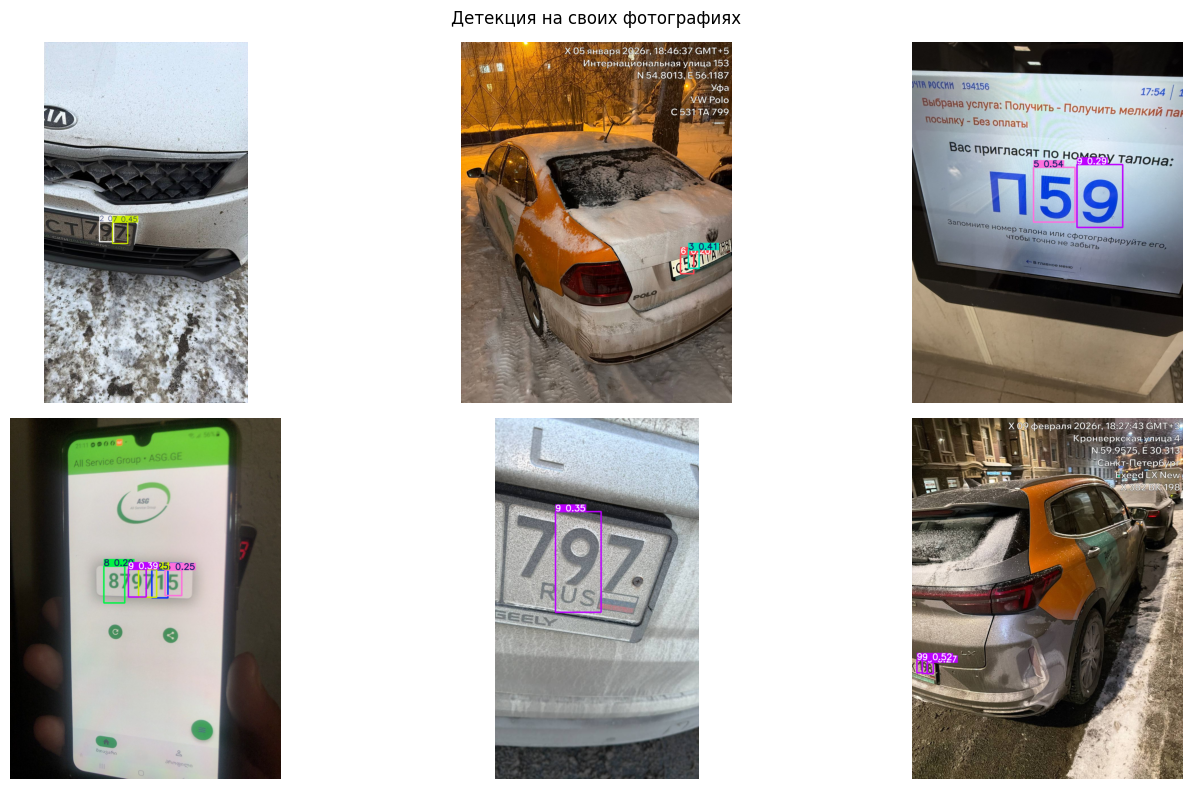

In [69]:
n = len(detection_results)
cols = min(3, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = np.array(axes).flatten()

for ax, res in zip(axes, detection_results[:n]):
    ax.imshow(res.plot()[:, :, ::-1])
    ax.axis("off")

plt.suptitle(f"Детекция на своих фотографиях", fontsize=12)
plt.tight_layout()
plt.show()

### Выводы

1. Удалось достичь требуемого качества, обучив на сравнительно слабом железе
2. Предобучение не дало ощутимого выигрыша. Я бы сказал, что такое возможно из-за большого размера датасета, на котором происходит дообучение. То есть трейн содержит репрезентативный набор запросов, так что этих данных хватает для достижения хорошего качества
3. Видим, что не все цифры на сделанных мной фотографиях распознаны. Вероятно, это происходит из-за неидеальной видимости цифр и из-за их нецентрального расположения, что нетипично для данных, на которых производилась валидация и обучение